# D1: A* Search with Admissible Heuristic Design

**FIT1061 Introduction to Artificial Intelligence — Distinction Task 1**

You implemented greedy best-first search at PASS level (P3). Greedy is fast but myopic: it commits to the first plausible direction and can blow past the optimum. **A\*** fixes this by combining the *cost so far* with the *heuristic estimate ahead*:

$$f(n) = g(n) + h(n)$$

where $g(n)$ is the path cost from the start to $n$, and $h(n)$ is your estimate of the remaining cost from $n$ to the goal. With an **admissible** heuristic — one that never *overestimates* the true remaining cost — A\* is guaranteed to return an optimal path.

In this task you:

1. Implement A\* on the 8-puzzle.
2. Design two heuristics — one trivial, one tighter — and argue that both are admissible.
3. Compare A\* (with both heuristics) against greedy and BFS empirically across many puzzles.
4. Reflect on why a tighter heuristic helps and what it costs.

> **Prerequisite:** P3 (Ready for Feedback). You'll reuse the priority queue idea.

> **Distinction level:** Less scaffolding. We provide the puzzle data structure, the priority queue, and reference BFS / greedy implementations. You write A\*, two heuristics, the empirical comparison, and the written analysis.

> **Domain: the 8-puzzle.** A 3x3 sliding-tile puzzle. Tiles 1..8 plus a blank. The goal is tiles 1..8 in row order with the blank in the bottom-right. You move by sliding a neighbour of the blank into the blank's cell. The 8-puzzle has the right size: small enough that BFS solves it (so we have an optimality reference), big enough that good heuristics make a visible difference (BFS expands hundreds of nodes; A\* with a tight heuristic expands tens).

---

## Setup

In [ ]:
from d1_helpers import (
    Puzzle8, PriorityQueue, Queue, SearchResult,
    is_solvable, random_puzzle, parse_state,
    visualise_puzzle, visualise_path,
    plot_search_comparison, plot_distribution_comparison,
    bfs_search, greedy_best_first_search,_reconstruct
)

import time
import random
from statistics import mean

print("Setup OK.")
print(f"Goal state: {Puzzle8.GOAL}")

Setup OK.
Goal state: (1, 2, 3, 4, 5, 6, 7, 8, 0)


---

## D1.1: Implement A\*

You will implement A\* on the 8-puzzle from scratch, using the provided `PriorityQueue` (same wrapper you used for greedy in P3).

A few things to notice:

- **The frontier is a priority queue keyed by $f(n) = g(n) + h(n)$.** This is the only structural change from greedy best-first (which is keyed by $h(n)$ alone).
- **Step cost is 1.** Each move of the blank costs one step, so $g(n)$ is just the depth of $n$ in the search tree.
- **You may need to revisit a node.** If you later find a strictly cheaper path to a node you have already reached, you will need to reconsider it rather than treat it as finished — think about what has to be updated when that happens. (With a *consistent* heuristic this cannot occur, but handling the general case keeps you safe.)

Also instrument your implementation: count how many nodes are *expanded* (popped from the frontier) and track the maximum size of the frontier. You'll need both for D1.3.

In [ ]:
def a_star(start, heuristic):
    """A* graph search on the 8-puzzle.

    Args:
        start: A Puzzle8 instance — the starting state.
        heuristic: A callable Puzzle8 -> non-negative number.

    Returns:
        SearchResult(path, nodes_expanded, max_frontier).
        path is a list of Puzzle8 instances from start to goal, or None
        if no path exists.
    """
    # --- YOUR CODE HERE ---
    frontier = PriorityQueue()
    frontier.push(start, priority=heuristic(start))
    came_from = {start: None}
    cost_so_far={start:0}
    nodes_expanded = 0  
    max_frontier = 1

    while not frontier.is_empty():
        max_frontier = max(max_frontier, frontier.size())
        current= frontier.pop()
        if current.is_goal():
            return SearchResult(_reconstruct(came_from, current), nodes_expanded, max_frontier)
            
        nodes_expanded+=1
        for neighbours in current.neighbours():
            new_cost=cost_so_far[current]+1
            if neighbours not in cost_so_far or new_cost<cost_so_far[neighbours]:
                cost_so_far[neighbours]=new_cost
                frontier.push(neighbours, priority=new_cost+heuristic(neighbours))
                came_from[neighbours]= current
    
              # delete this line once you start writing
            # --- END YOUR CODE ---
    
        # ---- Do not modify below this line ----
    return SearchResult(_reconstruct(came_from, current),
                                                nodes_expanded, max_frontier)
    
    # --- END YOUR CODE ---

Start state: Puzzle8(4, 1, 3, 7, 2, 5, 0, 8, 6)
A* path length: 6 moves
Nodes expanded: 56
Max frontier:   39

A* path found. Visualising:


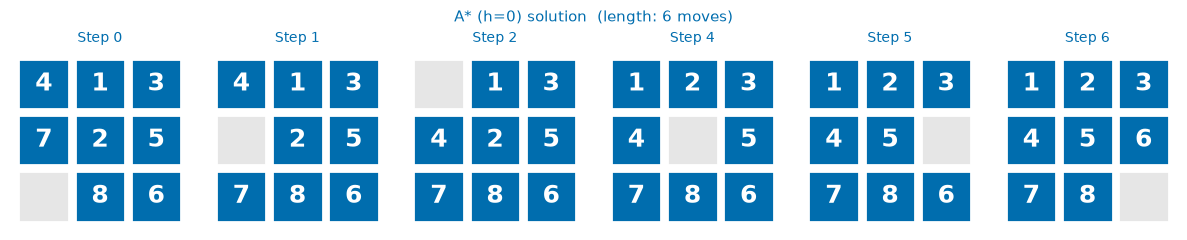

In [ ]:
# Smoke test: a 6-shuffle puzzle should solve very fast with any heuristic.
def h_zero(p):
    """Trivial heuristic that always returns 0.

    A* with h = 0 is just uniform-cost search, which on a unit-step graph
    is BFS. Useful as a sanity check while you're writing a_star.
    """
    return 0

start = random_puzzle(n_shuffles=6, seed=1)
print(f"Start state: {start}")

result = a_star(start, h_zero)
if result is None or result.path is None:
    print("⚠ a_star did not find a path. Implement it first, then re-run.")
else:
    print(f"A* path length: {len(result.path) - 1} moves")
    print(f"Nodes expanded: {result.nodes_expanded}")
    print(f"Max frontier:   {result.max_frontier}")
    print()
    print("A* path found. Visualising:")
    visualise_path(result.path, max_steps=6, title="A* (h=0) solution")

---

## D1.2: Heuristic design

A heuristic $h(n)$ is **admissible** if it never overestimates the true remaining cost from $n$ to the goal. Admissibility is what makes A\* optimal: any node whose $f(n) = g(n) + h(n)$ exceeds the true optimal cost can be safely skipped.

For the 8-puzzle, two classic admissible heuristics are:

- $h_1$ = number of misplaced tiles (blank excluded)
- $h_2$ = sum of Manhattan distances of each tile to its goal position

Both are admissible. $h_2$ **dominates** $h_1$ (that is, $h_2(n) \ge h_1(n)$ at every state), so A\* with $h_2$ expands no more nodes than A\* with $h_1$. (See AIMA §3.6.)

### What you implement

Implement **both** heuristics yourself. The trivial one ($h_1$) is a warm-up. The Manhattan-distance one ($h_2$) is your "tighter heuristic" for the task. Optional: if you want a third heuristic, the **linear-conflict** correction adds 2 for each pair of tiles in their goal row/column but in the wrong order (Hansson, Mayer, and Yung 1992).

In [ ]:
def h_misplaced(p):
    """h1: number of tiles not in their goal position (blank excluded).

    Args:
        p: Puzzle8 instance.

    Returns:
        int — count of tiles that are not where they should be.
    """
    # --- YOUR CODE HERE ---
    misplaced_count=0
    for i in range(9): 
        val=p.state[i]
        if val!= 0 and val != Puzzle8.GOAL[i]:
            misplaced_count+=1
    return misplaced_count
    # --- END YOUR CODE ---

In [ ]:
def h_manhattan(p):
    """h2: sum of Manhattan distances of tiles to their goal positions.

    Args:
        p: Puzzle8 instance.

    Returns:
        int — sum of |dr| + |dc| over all non-blank tiles.
    """
    # --- YOUR CODE HERE ---
    total_distance=0
    for i in range(9):
        val=p.state[i]
        if val != 0:
            goal_index=Puzzle8.GOAL.index(val)
            current_r=i//3
            current_c=i%3
            goal_r=goal_index//3
            goal_c=goal_index%3
            total_distance+=abs(current_r-goal_r)+abs(current_c-goal_c)
    return total_distance
    # --- END YOUR CODE ---

In [ ]:
# Sanity checks for the heuristics

# 1. At the goal state, every heuristic should return 0.
goal = Puzzle8(Puzzle8.GOAL)
print(f"At goal: h1 = {h_misplaced(goal)}, h2 = {h_manhattan(goal)}")
assert h_misplaced(goal) == 0, "h_misplaced(goal) should be 0"
assert h_manhattan(goal) == 0, "h_manhattan(goal) should be 0"

# 2. h2 dominates h1: on any reachable state, h2 >= h1.
rng = random.Random(0)
for _ in range(100):
    p = random_puzzle(n_shuffles=rng.randint(2, 20),
                      seed=rng.randint(0, 10_000))
    h1, h2 = h_misplaced(p), h_manhattan(p)
    assert h2 >= h1, f"dominance broken on {p}: h1={h1}, h2={h2}"
print("OK: h2 dominates h1 on 100 random instances.")

# 3. Compare on one example.
demo = parse_state("123405678")
print(f"\nDemo state {demo.state}: h1 = {h_misplaced(demo)}, h2 = {h_manhattan(demo)}")

At goal: h1 = 0, h2 = 0
OK: h2 dominates h1 on 100 random instances.

Demo state (1, 2, 3, 4, 0, 5, 6, 7, 8): h1 = 4, h2 = 6


In [ ]:
# Run A* with each heuristic on the same start state and report node counts.
start = random_puzzle(n_shuffles=18, seed=42)
print(f"Start state: {start}")

for name, h in [("zero",       h_zero),
                ("misplaced",  h_misplaced),
                ("Manhattan",  h_manhattan)]:
    r = a_star(start, h)
    print(f"A* (h={name:>10}): path {len(r.path) - 1} moves, "
          f"{r.nodes_expanded:>5d} nodes expanded, max frontier {r.max_frontier}")

print()
print("Notice: all three return the SAME path length (admissible heuristics")
print("preserve optimality). Only the number of nodes expanded differs.")

Start state: Puzzle8(1, 2, 3, 4, 0, 5, 7, 8, 6)
A* (h=      zero): path 2 moves,    12 nodes expanded, max frontier 8
A* (h= misplaced): path 2 moves,     2 nodes expanded, max frontier 5
A* (h= Manhattan): path 2 moves,     2 nodes expanded, max frontier 5

Notice: all three return the SAME path length (admissible heuristics
preserve optimality). Only the number of nodes expanded differs.


### Argue admissibility (2-3 paragraphs)

You implemented two heuristics. **Argue, in your own words, that each one is admissible**: that it never overestimates the true remaining cost. Be specific about *why* the bound holds, not just that it does.

Hints to ground your argument:

- For $h_1$ (misplaced tiles): every misplaced tile must move at least once before reaching its goal cell. What does that imply about the total number of moves remaining?
- For $h_2$ (Manhattan distance): each move slides exactly one tile by exactly one cell. What does that imply about how fast Manhattan distance can decrease per move?

> _Your admissibility argument here._

 Admissible just mean it counts less than the chrtest path
> _Paragraph 1: h_1 admissibility._

   As misplaced heruistic, it counts if this number is in the correct place. There is some case that it is different number but it is very far, then the actual action will move a lot of time, but in misplaced heuristc will only count if it is on the right positison, so will always be lesser than the actual movement. 
> _Paragraph 2: h_2 admissibility._

manhattan herustic counts the distance between target and goal, but it ignore all the obstacle between target and goal, which is still lesser than the real steps. 
> _Paragraph 3 (optional): why h_2 dominates h_1._

The closer count to real steps is a better heurstic, we can assure both is lesser than real steps, but manhattan will always be larger or equal to misplaced 

---

## D1.3: Empirical comparison

You will now run BFS, greedy best-first (with Manhattan), and A\* (with both heuristics) on at least **10** randomly-generated puzzles. For each algorithm and each instance, record:

- `nodes_expanded`: the number of states popped from the frontier
- `path_length`   : number of moves in the returned path (or None if no path)
- `time_seconds`  : wall-clock time

Then summarise across instances. Look for:

- **Optimality:** all three A\* runs should return the same path length on every instance; greedy may not.
- **Effort:** A\* with $h_2$ should expand strictly fewer nodes than A\* with $h_1$ on most instances (dominance).
- **Trade-off:** greedy is fast but may find a longer path.

Use the provided `plot_search_comparison` and `plot_distribution_comparison` helpers for the figures.

algorithm            |   mean nodes |      mean time | mean path
----------------------------------------------------------------
BFS                  |       909.42 |       0.005295 |       5.33
Greedy (Manhattan)   |         8.42 |       0.000082 |       5.33
A* (misplaced)       |        45.08 |       0.000288 |       5.33
A* (Manhattan)       |        10.08 |       0.000093 |       5.33


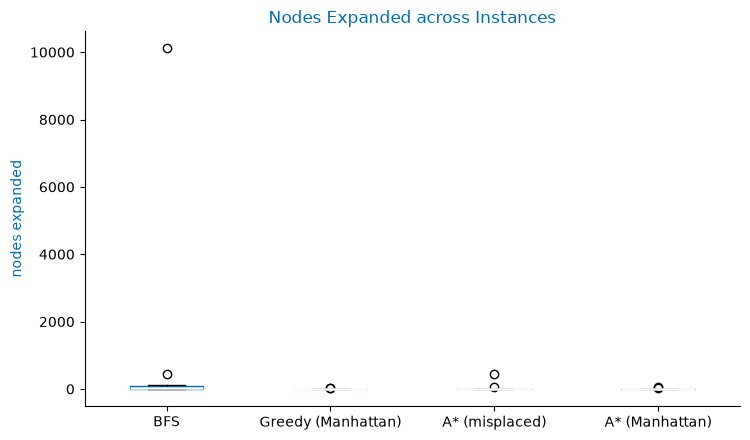

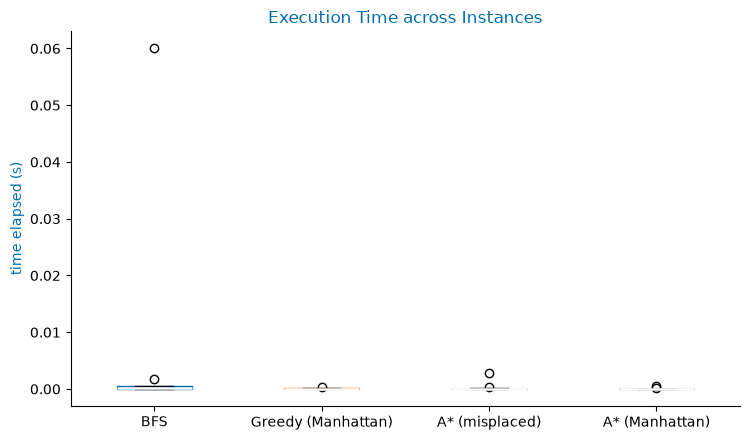

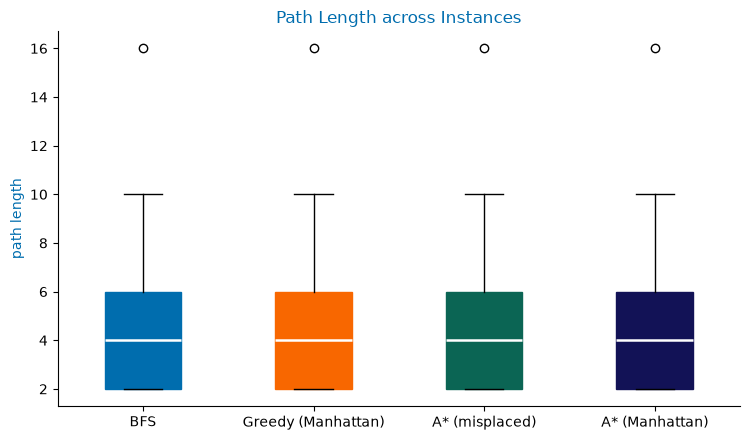

In [ ]:
# --- YOUR CODE HERE ---
# 1. Set N = 12 (or more — anything >= 10 is fine for the task).
# 2. Use random.Random(42) to generate instance seeds reproducibly.
# 3. For each instance:
#      - start = random_puzzle(n_shuffles=18, seed=<a seed>)
#      - skip if not is_solvable(start)   (random_puzzle is always solvable,
#        but include the check as defensive practice)
#      - for each algorithm, run it and record nodes_expanded, path_length,
#        and time.perf_counter() elapsed.
# 4. Store ONE dict per metric, each keyed by algorithm name, with a flat
#    list of scalar values (one entry per instance):
#        results_nodes = {"BFS": [], "Greedy (Manhattan)": [],
#                         "A* (misplaced)": [], "A* (Manhattan)": []}
#        results_time  = {k: [] for k in results_nodes}
#        results_path  = {k: [] for k in results_nodes}
#    plot_distribution_comparison plots ONE metric at a time, so this shape
#    lets you pass results_nodes straight in — no reshaping needed.
# 5. Print a summary table: algorithm | mean nodes | mean time | mean path.

# Hint: greedy_best_first_search(start, h_manhattan) and bfs_search(start)
# are provided by d1_helpers. You wrote a_star above.

# --- END YOUR CODE ---
N=12
instance_seeds_reproduce=random.Random(42)
results_nodes = {"BFS": [], "Greedy (Manhattan)": [],"A* (misplaced)": [], "A* (Manhattan)": []}


result_time={k:[] for k in results_nodes}
result_path={k:[] for k in results_nodes}

count=0
while count< N:
    seeds=instance_seeds_reproduce.randint(0,1000000)
    start=random_puzzle(n_shuffles=18, seed=seeds)

    if not is_solvable(start):
        continue
    count+=1
    algorithm_run={
        "BFS":lambda: bfs_search(start) , "Greedy (Manhattan)": lambda: greedy_best_first_search(start, h_manhattan), "A* (misplaced)":lambda: a_star(start, h_misplaced),"A* (Manhattan)":lambda:a_star(start, h_manhattan),
    }
    for name, func in algorithm_run.items():
        t0= time.perf_counter()
        result=func()#run 
        elapsed= time.perf_counter()-t0

        results_nodes[name].append(result.nodes_expanded)
        result_time[name].append(elapsed)
    
        if result is not None and result.path is not None:
            path_len=len(result.path)-1
        else:
            path_len= 0
        result_path[name].append(path_len)
print(f"{'algorithm':<20} | {'mean nodes':>12} | {'mean time':>14} |{'mean path':>10}")
print("-" * 64)
for algoritem in results_nodes:
    mean_node=sum(results_nodes[algoritem])/len(results_nodes[algoritem])
    mean_time=sum(result_time[algoritem])/len(result_time[algoritem])
    mean_path=sum(result_path[algoritem])/len(result_path[algoritem])
    print(f"{algoritem:<20} | {mean_node:>12.2f} | {mean_time:>14.6f} | {mean_path:>10.2f}")
plot_distribution_comparison(
    results_nodes,
    metric_name="nodes expanded",
    title="Nodes Expanded across Instances",
)
plot_distribution_comparison(
    result_time,
    metric_name="time elapsed (s)",
    title="Execution Time across Instances",
)
plot_distribution_comparison(
    result_path,
    metric_name="path length",
    title="Path Length across Instances",
)






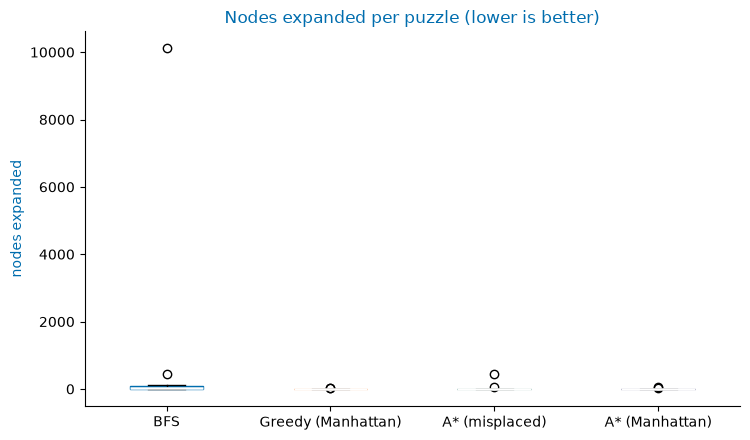

In [ ]:
# Once your loop runs, the plot call below should work as-is.
# results_nodes is keyed by algorithm name, with each value a list of the
# per-instance nodes-expanded counts — exactly the shape
# plot_distribution_comparison wants, so it goes straight in.
# (Rename to match your variable if you called it something else.)

try:
    plot_distribution_comparison(
        results_nodes,
        metric_name="nodes expanded",
        title="Nodes expanded per puzzle (lower is better)"
    )
except NameError:
    print("`results_nodes` is not defined yet — run your D1.3 loop above first.")
except Exception as e:
    print(f"Plot call failed: {e}")
    print("results_nodes must be keyed by algorithm name, each value a flat "
          "list of scalar node counts — see the hint above.")


---

## D1.4: Reflection

Write your answers below (3-4 sentences each).

1. **Why does a tighter heuristic help?** Use your D1.3 numbers to support the answer. Concretely: when you switched from $h_1$ to $h_2$, what happened to the mean nodes expanded? What is the intuition behind the change?

2. **What does a tighter heuristic cost?** Computing $h_2$ takes more work per node than $h_1$. When could this matter? Look at your mean wall-clock time: did $h_2$ win on time too, or only on node count?

3. **When should you stop tightening?** Imagine you found an even tighter heuristic (say, the cost of solving a relaxed version of the problem optimally). When would that pay off? When would it not?

4. **Optimality vs effort vs path quality.** Greedy was probably the fastest of the three but returned non-optimal paths on some instances. When is "fast but suboptimal" the right choice? When is "slow but optimal" worth the wait?

> _Your reflection here._
>
> _Answer to question 1._
>
According to our test, Manhattan Distance, which is the tighter herustici perform better than misplaced, as the result of my program, misplace A* have mean node at 45, whereas Manhattan A* has only 10 nodes. The time is also better in mahatten with 0.000093, 1/3 of misplace A* run time. 
> _Answer to question 2._
>
it cost more on computing the heuristic, but overall, we will need to see the result time(heurstic time+ node expanded time) because more accurate herustic tends to have more complex computation so at the end of the test it might not be faster depands on the test.  The time is lesser in manhattan A* is because it explore lesser node, so even each heuristic cost more time, the overall time is lesser than misplaced A*

> _Answer to question 3._
>
when the problem is very small, having too tight heurstic will eventually be slower, since it might take more computation on heuristic. As a complex task that might lead to multiple result, using a tighter heurstic can save a lot of time and space, for this asssignment, if the puzzle is larger than 10, ram will ran out of space to store, even using A* can't really solve it. 
> _Answer to question 4._

When you need a faster reaction but don't care if is best result, greedy is a better selution. When you need the best solution in a small task, BFS will be the best choice overall, because it explore more nodes(slow) but have the shortest path(best result).

---

## Check your understanding

Run the cell below and answer the quick quiz. The quiz does not grade your work; it's a self-check before you submit.


In [ ]:
from jupyterquiz import display_quiz

d1_quiz = [
    {
        "question": "Why does A* with an admissible heuristic always return an optimal path?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "Because f(n) = g(n) + h(n) is a lower bound on the true cost through n, A* never expands a node whose f exceeds the optimal cost.", "correct": True,
             "feedback": "Correct. Admissibility means h(n) underestimates the remaining cost, so f(n) underestimates the total cost through n. A* pops nodes in increasing f order, so when it reaches the goal it has already explored every state that could lead to a cheaper solution."},
            {"answer": "Because it expands nodes in order of decreasing h(n).", "correct": False,
             "feedback": "That would be greedy best-first search — not A*. Greedy is not optimal."},
            {"answer": "Because A* uses BFS internally to verify the path.", "correct": False,
             "feedback": "A* does not run BFS internally. The optimality comes from the f-ordering and the admissibility of h."},
            {"answer": "Because the priority queue tie-breaks in favour of shorter paths.", "correct": False,
             "feedback": "Tie-breaking helps efficiency but is not what guarantees optimality. The admissibility of h is what does."},
        ],
    },
    {
        "question": "On 100 random 8-puzzles, A* with h_manhattan expanded 11 nodes on average and A* with h_misplaced expanded 21. Why?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "h_manhattan dominates h_misplaced — its values are at least as large at every state — so A* with h_manhattan can prune more nodes while remaining optimal.", "correct": True,
             "feedback": "Correct. A tighter (but still admissible) heuristic gives larger lower bounds, which lets A* dismiss more nodes early. The optimal solution is unchanged, but the search effort drops."},
            {"answer": "h_manhattan is faster to compute than h_misplaced.", "correct": False,
             "feedback": "Per-node compute time is the OPPOSITE here — h_manhattan does more arithmetic per state. But it pays off because A* expands far fewer states overall."},
            {"answer": "h_manhattan is inadmissible, so A* skips bad paths faster.", "correct": False,
             "feedback": "h_manhattan is admissible. Inadmissibility would break the optimality guarantee. The win comes from h being *tighter while remaining admissible*."},
            {"answer": "h_misplaced returns 0 on some non-goal states.", "correct": False,
             "feedback": "h_misplaced returns 0 only at the goal (and at any state with no misplaced tiles, which equals the goal for the 8-puzzle). That's not the explanation."},
        ],
    },
    {
        "question": "When would greedy best-first search be the right choice over A* on the 8-puzzle?",
        "type": "multiple_choice",
        "answers": [
            {"answer": "When you need ANY path quickly and can tolerate it being non-optimal.", "correct": True,
             "feedback": "Correct. Greedy expands far fewer nodes than A* but does not guarantee optimality. If a quick approximate solution is good enough — e.g. real-time planning under tight compute budget — greedy is the right tool. If you need the true shortest path, use A*."},
            {"answer": "When the heuristic is inadmissible.", "correct": False,
             "feedback": "Greedy works regardless of admissibility — but so does A*, just without the optimality guarantee. The real reason to pick greedy is compute budget, not heuristic quality."},
            {"answer": "When the puzzle is unsolvable.", "correct": False,
             "feedback": "Both algorithms detect unsolvable instances by exhausting the search space. Picking greedy doesn't help here."},
            {"answer": "When you don't have a priority queue available.", "correct": False,
             "feedback": "Both algorithms need a priority queue. Greedy's is keyed by h(n); A*'s by g(n) + h(n)."},
        ],
    },
]

display_quiz(d1_quiz, shuffle_answers=True)

<IPython.core.display.Javascript object>

---

## Submission checklist

- [x ] **D1.1:** `a_star` function implemented and finds the goal on the smoke-test puzzle.
- [x ] **D1.1:** A* solution path visualised.
- [x ] **D1.2:** `h_misplaced` and `h_manhattan` implemented; both return 0 at the goal; h2 dominates h1 on the random check.
- [x ] **D1.2:** Admissibility argument written (2-3 paragraphs in your own words).
- [x ] **D1.3:** Empirical comparison loop run on at least 10 random puzzles.
- [x ] **D1.3:** Distribution plot generated for nodes expanded.
- [x ] **D1.3:** Summary printed: mean nodes, mean time, mean path length per algorithm.
- [x ] **D1.4:** Four reflection answers written (3-4 sentences each).
- [x ] Quiz completed.
- [x ] All files uploaded to OnTrack.
- [x ] Task marked as **Ready for Feedback**.

---

> **AI use policy (Distinction level):**
> You may use AI to explain concepts or to debug specific errors. You may **not** use AI to generate the A* implementation, the heuristics, the admissibility argument, or the reflection. Cite all AI use.

---
I use ai in debugging and some usage example, like how to use lamda. 

*FIT1061 Distinction Task 1: A* Search with Admissible Heuristic Design*